# Importing Libraries

In [1]:
import sys
sys.path.append('../')

import numpy as np
from pathlib import Path 
from pylops.utils import *
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from devito import configuration
from scipy.ndimage import gaussian_filter
from pylops.waveeqprocessing.twoway import PetroAcousticWave2D
from PetroFWI import PetroAcoustic_FWI_Multiscale

configuration['log-level'] = 'ERROR'
from seis2rock.pem_seis2rock import pem_seis2rock

# Loading Data

In [2]:
BASE_DIR = Path.cwd()
path = BASE_DIR.parent / "data" / "smeaheia_petrophysics.npz"

phi_orig, vsh_orig, sw_orig, depth = np.load(path)['phi'], np.load(path)['vsh'], np.load(path)['sw'], np.load(path)['depth']
xaxis, nx, nz, dz = np.load(path)['xaxis'], np.load(path)['nx'], np.load(path)['nz'], np.load(path)['dz']

print(f'nx:{nx}, nz:{nz}, dz:{dz}')

nx:174, nz:225, dz:11.16071428571422


In [3]:
dx = xaxis[1] - xaxis[0]
dz = depth[1] - depth[0]

# Novo espaçamento
new_spacing = (25, 25)

# Fatores de escala (novo tamanho / antigo tamanho)
zoom_factors = (dx / new_spacing[0], dz / new_spacing[1])

# Redimensionar com interpolação "nearest"
phi = zoom(phi_orig, zoom_factors, order=0)
vsh = zoom(vsh_orig, zoom_factors, order=0)
sw = zoom(sw_orig, zoom_factors, order=0)

phi_min, phi_max = np.min(phi), np.max(phi)
vsh_min, vsh_max = np.min(vsh), np.max(vsh)
sw_min, sw_max = np.min(sw), np.max(sw)

# Add water column
water_lenght = 0                                # Water column thickness (m)
nwater = int(water_lenght / new_spacing[1])     # Number of samples of water column
nwater = 10

vp, vs, rho = pem_seis2rock(phi=phi, vsh=vsh, sw=sw)      # Calculate elastic properties using Seis2Rock (Gomes et al., 2024)

vp /= 1000      # Convert from m/s to km/s

In [4]:
# Modelling parameters (in meters, seconds and Hz)
par = {
    'nx': 98,   'dx': 25,     'ox': 0.,
    'nz': 100,  'dz': 25,     'oz': 0.,
    'ns': 20,   'ds': 175,    'sz': 0.,
    'nr': 98,   'dr': 25,     'rz': 0.,
    'nt': 3000, 'dt': 0.002,   't0': 0.,
    'nw': 5,   'freq': 20
}

coef = {'a1': -0.43, 'a2': 0.88, 'a3': 0.57, 'a4': 1.72}

shape = (par['nx'], par['nz'])
spacing = (par['dx'], par['dz'])
origin = (par['ox'], par['oz'])
src_type = 'Ricker' # or 'Ricker_Devito' if you want to use Devito Source
dtype = np.float32
space_order = 8
nbl = 50

In [5]:
# Setting receivers positions
x_r = np.zeros((par['nr'], 2))
x_r[:, 0] = np.arange(par['nr']) * par['dr'] # receivers positions
x_r[:, 1] = par['rz']

# Setting source positions
model_domain_size = ((shape[0]-1)*spacing[0], (shape[1]-1)*spacing[1])
x_s = np.zeros((par['ns'], 2))
x_s[:,0] = np.linspace(0., model_domain_size[0], num=par['ns'])
x_s[:,1] = origin[1] + spacing[1] * 2

# x_s[:, 0] = np.arange(par['ns']) * par['ds'] # source positions
# x_s[:, 1] = par['sz']

# Setting propagation time
# tn = (np.arange(par['nt'])*par['dt'])[-1]

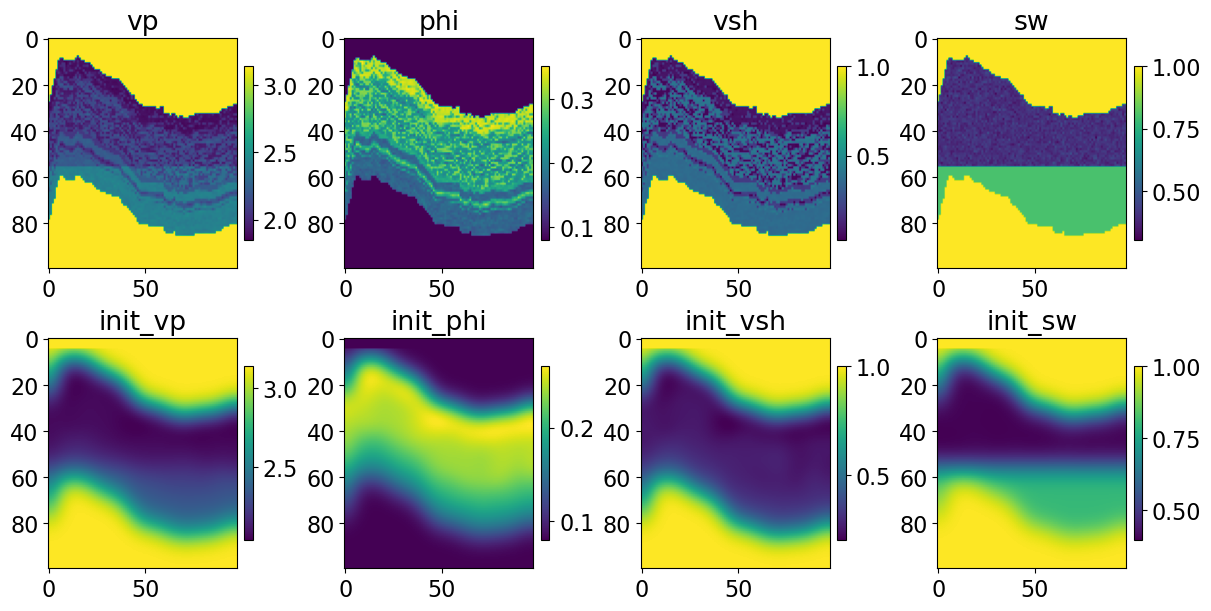

In [6]:
init_phi = gaussian_filter(phi, sigma=(5,5))
init_vsh = gaussian_filter(vsh, sigma=(5,5))
init_sw = gaussian_filter(sw, sigma=(5,5))
init_vp = gaussian_filter(vp, sigma=(5,5))

init_phi[:,0:par['nw']] = phi[:,0:par['nw']]
init_vsh[:,0:par['nw']] = vsh[:,0:par['nw']]
init_sw[:,0:par['nw']] = sw[:,0:par['nw']]
init_vp[:,0:par['nw']] = vp[:,0:par['nw']]

fig, axs = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)

dados  = [vp, phi, vsh, sw, init_vp, init_phi, init_vsh, init_sw]
titulos = ["vp", "phi", "vsh", "sw", "init_vp", "init_phi", "init_vsh", "init_sw"]

for ax, arr, t in zip(axs.flat, dados, titulos):
    im = ax.imshow(arr.T, aspect='auto', cmap='viridis')
    ax.set_title(t)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [7]:
Dop = PetroAcousticWave2D(shape=shape,origin=origin, spacing=spacing, vp=vp*1e3, phi=phi, vsh=vsh, sw=sw, nbl=nbl, 
                          space_order=space_order,src_x=x_s[:,0], src_z=x_s[:,1], rec_x=x_r[:,0],
                          rec_z=x_r[:,1], t0=par['t0'], tn=par['nt'], src_type=src_type, f0=par['freq'],
                          dtype=dtype,op_name="fwd", dt=par['dt']*1e3, multi_input=True, **coef)

In [8]:
params = np.stack([phi, vsh, sw])

dobs = Dop*params

In [9]:
min_max_list = [(phi_min,phi_max), (vsh_min, vsh_max), (sw_min, sw_max)]

fwi = PetroAcoustic_FWI_Multiscale(operator=Dop,
                           vp_init=init_vp,
                           phi_init=init_phi,
                           vsh_init = init_vsh,
                           sw_init = init_sw,
                           dobs=dobs)

phi_inv, vsh_inv, sw_inv, fo, dobsfilt = fwi.run(ftarg=2, 
                                                 iterations=30, 
                                                 witer=10,
                                                 step=3,
                                                 min_max=min_max_list,
                                                 water_layer=par['nw'],freqs=None)

Working with frequency: 2.0 Hz -> 1/7
Iteration  1
FO:  11761.082295194681

Iteration  2
FO:  8000.786752424775

Iteration  3
FO:  3635.513818739092

Iteration  4
FO:  2424.4347834639893

Iteration  5
FO:  1857.0060535640143

Iteration  6
FO:  1452.2105884204561

Iteration  7
FO:  1237.420119496273

Iteration  8
FO:  1079.6414686684923

Iteration  9
FO:  969.9813940014626

Iteration  10
FO:  879.3880182001315

Iteration  11
FO:  804.4533085214651

Iteration  12
FO:  738.6770476150758

Iteration  13
FO:  680.1666610623834

Iteration  14
FO:  627.5261975215094

Iteration  15
FO:  580.0623857924901

Iteration  16
FO:  537.4366331330664

Iteration  17
FO:  498.4817081546088

Iteration  18
FO:  465.0488677432646

Iteration  19
FO:  431.0449063869063

Iteration  20
FO:  403.9127703555016

Iteration  21
FO:  375.60259249024006

Iteration  22
FO:  361.0497731429858

Iteration  23
FO:  352.6476811197216

Iteration  24
FO:  346.933101049823

Iteration  25
FO:  325.1906024002241

Iteration  26
FO

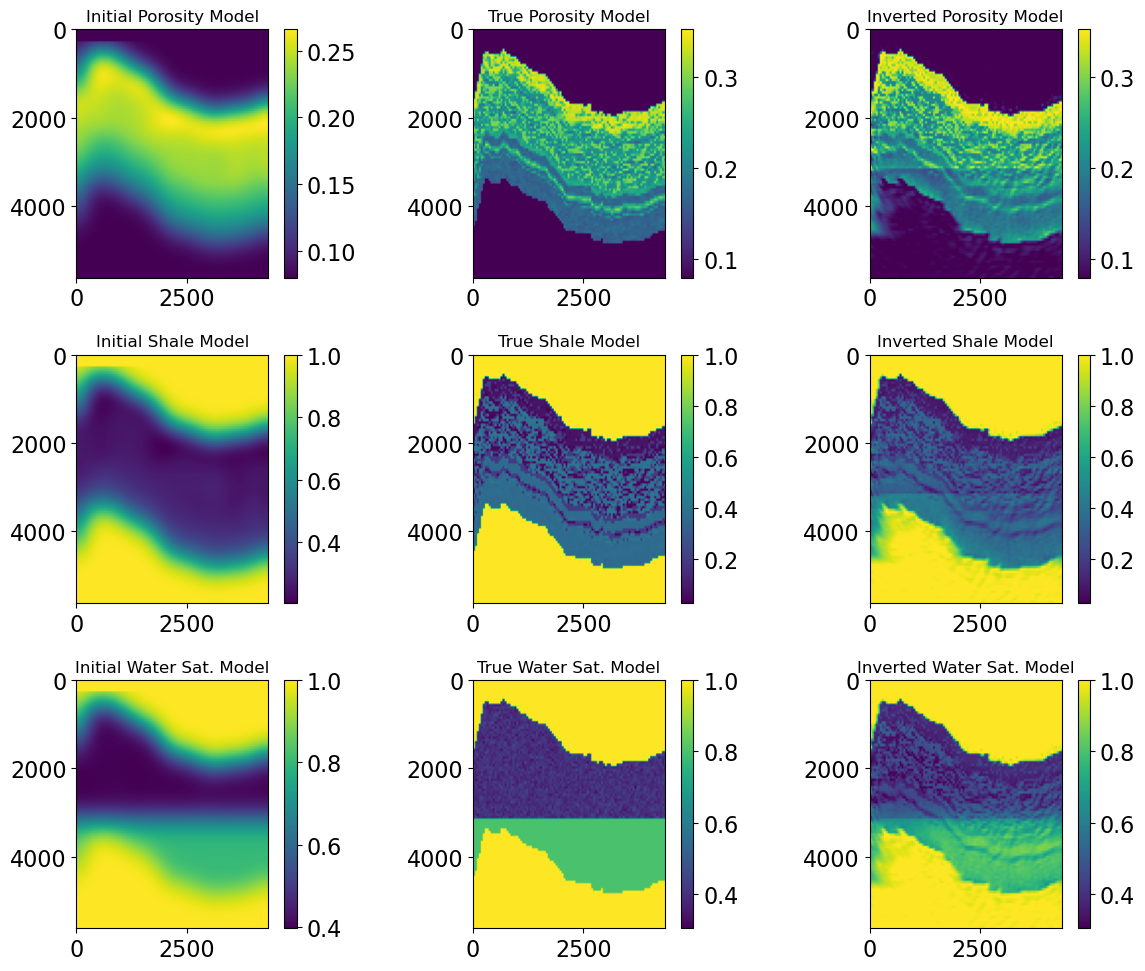

In [10]:
extent = [0, nx*spacing[0], nz*spacing[1], 0]
plt.figure(figsize=(12,10))
plt.subplot(3,3,1)
plt.imshow(init_phi.T, cmap='viridis',extent=extent)
plt.title('Initial Porosity Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,2)
plt.imshow(phi.T, cmap='viridis',extent=extent)
plt.title('True Porosity Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,3)
plt.imshow(phi_inv.T, cmap='viridis',extent=extent)
plt.title('Inverted Porosity Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,4)
plt.imshow(init_vsh.T, cmap='viridis',extent=extent)
plt.title('Initial Shale Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,5)
plt.imshow(vsh.T, cmap='viridis',extent=extent)
plt.title('True Shale Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,6)
plt.imshow(vsh_inv.T, cmap='viridis',extent=extent)
plt.title('Inverted Shale Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,7)
plt.imshow(init_sw.T, cmap='viridis',extent=extent)
plt.title('Initial Water Sat. Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,8)
plt.imshow(sw.T, cmap='viridis',extent=extent)
plt.title('True Water Sat. Model', fontsize=12)
plt.colorbar()
plt.subplot(3,3,9)
plt.imshow(sw_inv.T, cmap='viridis',extent=extent)
plt.title('Inverted Water Sat. Model', fontsize=12)
plt.colorbar()
plt.tight_layout()
# plt.savefig('Results_PylopsPetroAcousitc_FWI.png', format='png', dpi=200)

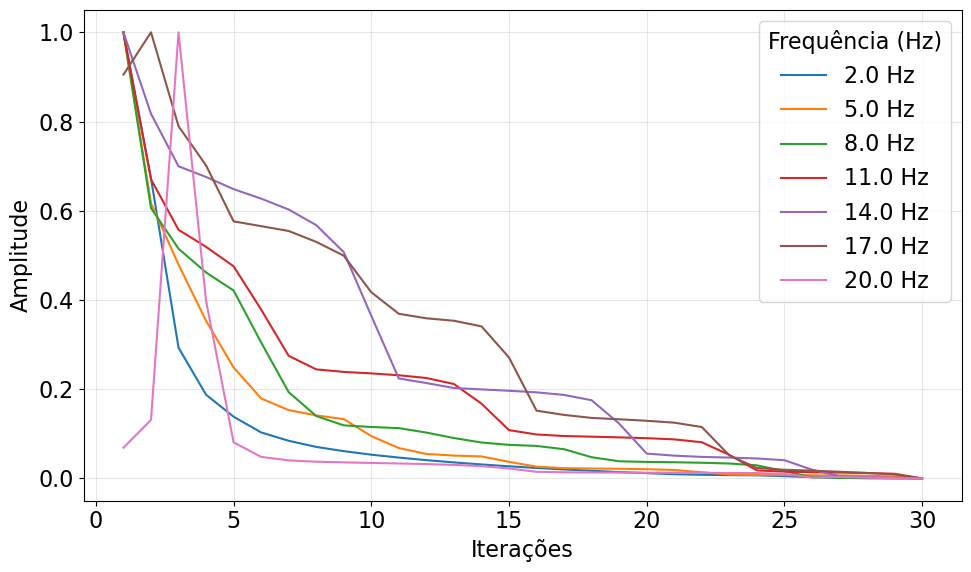

In [11]:
plt.figure(figsize=(10, 6))

for banda, valores in sorted(fo.items()):
    valores = np.array(valores)
    valores_norm = (valores - valores.min()) / (valores.max() - valores.min())

    x = range(1, len(valores_norm) + 1)
    plt.plot(x, valores_norm, label=f'{banda} Hz')

plt.xlabel('Iterations')
plt.ylabel('Amplitude')
plt.legend(title='Frequency (Hz)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('FO_PylopsPetroAcousitc_FWI.png', format='png', dpi=200)
plt.show()